# Multiple Choice Question Evaluation for Zeolite Synthesis

**Multi-Model & Multi-K Comparison**

This notebook evaluates LLM performance on multiple-choice questions about zeolite synthesis.

**Models Compared:**
- Mistral-7B-Instruct-v0.1 (GPU 3)
- Llama-3-8B-Instruct (GPU 2)

**Configurations:**
- k=10 and k=20 for all retrieval methods
- 7 retrieval methods: Abstract baseline, No context, FAISS, MMR, BM25, Hybrid, LLM-Optimized

**Note:** This notebook uses **TWO GPUs** (GPU 2 and GPU 3) for parallel model hosting.

Run with kernel v6 instead of v7

In [21]:
# Core imports
import os
import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import gc

# LangChain and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Load HuggingFace token
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")

In [22]:
!nvidia-smi

Wed Feb 18 15:22:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   28C    P8             11W /  230W |     985MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
!kill -9 1700376 

/bin/bash: line 0: kill: (1700376) - No such process


In [24]:
# Model Configuration
MODELS = {
    'mistral': {
        'name': 'mistralai/Mistral-7B-Instruct-v0.1',
        'display_name': 'Mistral-7B-Instruct',
        'gpu': 'cuda:3'
    },
    'llama': {
        'name': 'meta-llama/Meta-Llama-3-8B-Instruct',
        'display_name': 'Llama-3-8B-Instruct',
        'gpu': 'cuda:2'
    }
}

K_VALUES = [10, 20]
METHODS = ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

def load_model(model_key):
    """
    Load a model on a specific GPU.
    
    Args:
        model_key: Key from MODELS dictionary ('mistral' or 'llama')
    
    Returns:
        tuple: (llm, model, tokenizer) - LangChain LLM and underlying components
    """
    config = MODELS[model_key]
    model_name = config['name']
    device = config['gpu']
    
    print(f"\n{'='*80}")
    print(f"Loading {config['display_name']} on {device}...")
    print(f"{'='*80}")
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        use_fast=False,
        token=hf_token
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map=device,  # This already places the model on the correct GPU
        trust_remote_code=True,
        torch_dtype=torch.float16,
        token=hf_token
    )
    
    # Set up pipeline - DON'T specify device since model is already on correct GPU
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=2000
        # device parameter removed - model already on correct GPU via device_map
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    
    print(f"✓ {config['display_name']} loaded successfully on {device}")
    
    return llm, model, tokenizer

def cleanup_model(model, tokenizer):
    """Clean up model from GPU memory."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("✓ GPU memory cleared")

print("✓ Model management functions defined")

✓ Model management functions defined


In [25]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. 

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.
Context:
{context}

Question: {question}
"""

In [26]:
def evaluate_mc_response(llm, query, correct_answer, context):
    """Evaluate a single multiple choice question with context."""
    mc_prompt = ChatPromptTemplate.from_template(MC_PROMPT)
    chain = LLMChain(llm=llm, prompt=mc_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(context=context, question=query)
        
        # Find the last occurrence of "Answer: " (to avoid the example)
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            # Get the character right after "Answer: "
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                # Try to get explanation if available
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]  # Get just the answer line
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'context': context,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        # If we get here, no valid answer was found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

def evaluate_mc_no_context(llm, query, correct_answer):
    """Evaluate a single multiple choice question WITHOUT context."""
    NO_CONTEXT_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.

Question: {question}"""
    
    no_context_prompt = ChatPromptTemplate.from_template(NO_CONTEXT_PROMPT)
    chain = LLMChain(llm=llm, prompt=no_context_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(question=query)
        
        # Find the last occurrence of "Answer: "
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ Evaluation functions defined (with LLM parameter)")

✓ Evaluation functions defined (with LLM parameter)


In [27]:
def get_faiss_context(query, k=10):
    """Retrieve context using FAISS similarity search."""
    results = vector_db.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_mmr_context(query, k=10):
    """Retrieve context using Maximum Marginal Relevance."""
    results = vector_db.max_marginal_relevance_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_bm25_context(query, k=10):
    """Retrieve context using BM25 retriever."""
    results = bm25_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_hybrid_context(query, k=10):
    """Retrieve context using hybrid (ensemble) retriever."""
    results = ensemble_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_optimized_context(query, llm, k=10):
    """Retrieve context using LLM-optimized retrieval."""
    # Generate search query using LLM
    optimize_prompt = ChatPromptTemplate.from_template(OPTIMIZE_QUERY_PROMPT)
    chain = LLMChain(llm=llm, prompt=optimize_prompt)
    optimized_query = chain.run(question=query)
    
    # Use optimized query for retrieval
    results = vector_db.similarity_search(optimized_query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

# Unified evaluation function for all methods
def evaluate_method(llm, method_name, questions_df, k=10):
    """
    Evaluate a specific retrieval method.
    
    Args:
        llm: LangChain LLM instance
        method_name: Name of the method ('abstract', 'no_context', 'faiss', etc.)
        questions_df: DataFrame with questions
        k: Number of documents to retrieve
    
    Returns:
        dict: Results with accuracy and detailed responses
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        if method_name == 'abstract':
            # Use the pre-existing abstract context
            context = row['Context']
            result = evaluate_mc_response(llm, query, correct_answer, context)
        elif method_name == 'no_context':
            # No context - direct question answering
            result = evaluate_mc_no_context(llm, query, correct_answer)
        elif method_name == 'faiss':
            context = get_faiss_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context)
        elif method_name == 'mmr':
            context = get_mmr_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context)
        elif method_name == 'bm25':
            context = get_bm25_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context)
        elif method_name == 'hybrid':
            context = get_hybrid_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context)
        elif method_name == 'optimized':
            context = get_optimized_context(query, llm, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context)
        else:
            raise ValueError(f"Unknown method: {method_name}")
        
        results.append(result)
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name,
        'k': k,
        'accuracy': accuracy,
        'correct_count': correct_count,
        'total': total,
        'detailed_results': results
    }

print("✓ Retrieval and unified evaluation functions defined")

✓ Retrieval and unified evaluation functions defined


In [28]:
# Load the vector database and retrieval components
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
faiss_retriever = vector_db.as_retriever(search_kwargs={"k": 10})
print(f"✓ Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"✓ Initialized BM25 retriever with {len(all_docs)} documents")

✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents
✓ Initialized BM25 retriever with 1474439 documents


In [29]:
# Define hybrid search function
from langchain.retrievers import EnsembleRetriever

def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    
    Args:
        query: Search query string
        vector_db: FAISS vector store
        bm25_retriever: BM25 retriever instance
        k_total: Total number of documents to return (default=10)
        k_bm25: Number of documents to retrieve from BM25 (default=10)
        k_mmr: Number of documents to retrieve from MMR (default=10)
        mmr_fetch_k: Candidate pool size for MMR (default=40)
        mmr_lambda: Diversity parameter for MMR (default=0.6)
    
    Returns:
        List of unique documents
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

# Create ensemble retriever for hybrid method
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever],
    weights=[0.5, 0.5]
)

print("✓ Hybrid search function and ensemble retriever defined")

✓ Hybrid search function and ensemble retriever defined


In [30]:
# Query optimizer prompt and function for LLM-optimized retrieval
OPTIMIZE_QUERY_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""

def optimize_query_for_mcq(question: str, llm) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    
    Args:
        question: Original MCQ question (with options A-E)
        llm: LangChain LLM instance
    
    Returns:
        Optimized search query string
    """
    try:
        # Create a simple prompt
        prompt_template = ChatPromptTemplate.from_template(OPTIMIZE_QUERY_PROMPT)
        chain = LLMChain(llm=llm, prompt=prompt_template)
        
        # Generate optimized query
        response = chain.run(question=question)
        
        # Extract only the generated part (after the prompt)
        if "Optimized query:" in response:
            optimized_query = response.split("Optimized query:")[-1].strip()
        else:
            optimized_query = response.strip()
        
        # Clean up any extra text after the first line
        optimized_query = optimized_query.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question  # Fallback to original if empty
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question  # Fallback to original question on error

print("✓ Query optimizer prompt and function defined")

✓ Query optimizer prompt and function defined


In [31]:
# Load the question dataset
mc_questions_df = pd.read_excel('questionbank(unedited).xlsx', sheet_name='Synthesis')
mc_questions_df = mc_questions_df.dropna(subset=['gpt_generated_question'])
mc_questions_df = mc_questions_df.rename(columns={
    'gpt_generated_question': 'Question',
    'gpt_generated_answer': 'Correct_Answer',
    'abstract': 'Context'
})
mc_questions_df['Correct_Answer'] = mc_questions_df['Correct_Answer'].str.strip().str.upper()

print(f"✓ Loaded {len(mc_questions_df)} questions from question bank")
print(f"✓ Columns: {list(mc_questions_df.columns)}")

✓ Loaded 39 questions from question bank
✓ Columns: ['Context', 'Question', 'Correct_Answer', 'doi']


## Multi-Model Multi-K Experiment

This section runs a comprehensive comparison:
- **Models**: Mistral-7B-Instruct (GPU 3) and Llama-3-8B-Instruct (GPU 2)
- **K values**: 10 and 20
- **Methods**: Abstract baseline, No context, FAISS, MMR, BM25, Hybrid, LLM-Optimized

**Total experiments**: 2 models × 2 k-values × 7 methods = 28 experimental conditions

In [ ]:
# Initialize results storage
all_results = {}
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Main experiment loop
for model_key in ['mistral', 'llama']:
    model_config = MODELS[model_key]
    model_display_name = model_config['display_name']
    
    # Load model
    llm, model, tokenizer = load_model(model_key)
    
    # Initialize storage for this model
    all_results[model_display_name] = {}
    
    # Loop through k values
    for k in K_VALUES:
        print(f"\n{'='*80}")
        print(f"Running experiments with k={k}")
        print(f"{'='*80}")
        
        all_results[model_display_name][f"k={k}"] = {}
        
        # Loop through methods
        for method in METHODS:
            print(f"\n--- Evaluating {method.upper()} with k={k} on {model_display_name} ---")
            
            try:
                # Special handling for 'no_context' - k doesn't apply
                if method == 'no_context':
                    result = evaluate_method(llm, method, mc_questions_df, k=k)
                else:
                    result = evaluate_method(llm, method, mc_questions_df, k=k)
                
                # Store results
                all_results[model_display_name][f"k={k}"][method] = result
                
                # Print summary
                print(f"✓ {method.upper()}: {result['accuracy']:.2f}% "
                      f"({result['correct_count']}/{result['total']})")
                
                # Save intermediate results
                temp_save_path = f'results_multimodel_intermediate_{timestamp}.json'
                with open(temp_save_path, 'w') as f:
                    json.dump(all_results, f, indent=2)
                
            except Exception as e:
                print(f"✗ Error evaluating {method}: {str(e)}")
                all_results[model_display_name][f"k={k}"][method] = {
                    'error': str(e),
                    'accuracy': 0,
                    'correct_count': 0,
                    'total': 0
                }
    
    # Clean up model before loading next one
    print(f"\n{'='*80}")
    print(f"Completed all experiments for {model_display_name}")
    print(f"{'='*80}")
    
    if model_key == 'mistral':  # Only cleanup between models, not after last
        cleanup_model(model, tokenizer)

# Final save
final_save_path = f'results_multimodel_final_{timestamp}.json'
with open(final_save_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n{'='*80}")
print(f"ALL EXPERIMENTS COMPLETED!")
print(f"Results saved to: {final_save_path}")
print(f"{'='*80}")


Loading Mistral-7B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Mistral-7B-Instruct loaded successfully on cuda:3

Running experiments with k=10

--- Evaluating ABSTRACT with k=10 on Mistral-7B-Instruct ---


Evaluating abstract (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating abstract (k=10):  13%|█▎        | 5/39 [00:03<00:23,  1.43it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating abstract (k=10):  26%|██▌       | 10/39 [00:07<00:22,  1.29it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating abstract (k=10):  26%|██▌       | 10/39 [00:07<00:22,  1.29it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Llama-3-8B-Instruct loaded successfully on cuda:2

Running experiments with k=10

--- Evaluating ABSTRACT with k=10 on Llama-3-8B-Instruct ---


Evaluating abstract (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Evaluating abstract (k=10):  26%|██▌       | 10/39 [05:43<15:05, 31.23s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Evaluating abstract (k=10):  26%|██▌       | 10/39 [05:43<15:05, 31.23s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

✓ ABSTRACT: 76.92% (30/39)

--- Evaluating NO_CONTEXT with k=10 on Llama-3-8B-Instruct ---


Evaluating no_context (k=10):   0%|          | 0/39 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Evaluating no_context (k=10):   3%|▎         | 1/39 [00:01<00:41,  1.09s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In 

## Results Analysis and Visualization

Now let's analyze and visualize the comprehensive results from all models, k values, and methods.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract results into a structured format for visualization
viz_data = []

for model_name in all_results.keys():
    for k_label in all_results[model_name].keys():
        k_value = int(k_label.split('=')[1])
        for method in all_results[model_name][k_label].keys():
            result = all_results[model_name][k_label][method]
            viz_data.append({
                'model': model_name,
                'k': k_value,
                'method': method,
                'accuracy': result.get('accuracy', 0),
                'correct': result.get('correct_count', 0),
                'total': result.get('total', 0)
            })

# Create DataFrame for easier manipulation
viz_df = pd.DataFrame(viz_data)

# Print summary table
print("\n" + "="*100)
print("COMPREHENSIVE RESULTS: ALL MODELS, K VALUES, AND METHODS")
print("="*100)
print(f"{'Model':<25} {'K':<5} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*100)

for _, row in viz_df.iterrows():
    print(f"{row['model']:<25} {row['k']:<5} {row['method']:<15} "
          f"{row['accuracy']:>6.2f}%      {row['correct']}/{row['total']}")

print("="*100)

# Find best overall configuration
best_idx = viz_df['accuracy'].idxmax()
best_config = viz_df.loc[best_idx]
print(f"\n✓ BEST: {best_config['model']} with {best_config['method']} (k={best_config['k']}): "
      f"{best_config['accuracy']:.2f}%")

# Find worst overall configuration
worst_idx = viz_df['accuracy'].idxmin()
worst_config = viz_df.loc[worst_idx]
print(f"✗ WORST: {worst_config['model']} with {worst_config['method']} (k={worst_config['k']}): "
      f"{worst_config['accuracy']:.2f}%")

print(f"\nΔ Overall Range: {best_config['accuracy'] - worst_config['accuracy']:.2f}%")
print("="*100)


COMPREHENSIVE RESULTS: ALL MODELS, K VALUES, AND METHODS
Model                     K     Method          Accuracy     Correct/Total  
----------------------------------------------------------------------------------------------------
Mistral-7B-Instruct       10    abstract         61.54%      24/39
Mistral-7B-Instruct       10    no_context       48.72%      19/39
Mistral-7B-Instruct       10    faiss             0.00%      0/0
Mistral-7B-Instruct       10    mmr               0.00%      0/0
Mistral-7B-Instruct       10    bm25             41.03%      16/39
Mistral-7B-Instruct       10    hybrid           41.03%      16/39
Mistral-7B-Instruct       10    optimized         0.00%      0/0
Mistral-7B-Instruct       20    abstract         61.54%      24/39
Mistral-7B-Instruct       20    no_context       48.72%      19/39
Mistral-7B-Instruct       20    faiss             0.00%      0/0
Mistral-7B-Instruct       20    mmr               0.00%      0/0
Mistral-7B-Instruct       20    bm25 

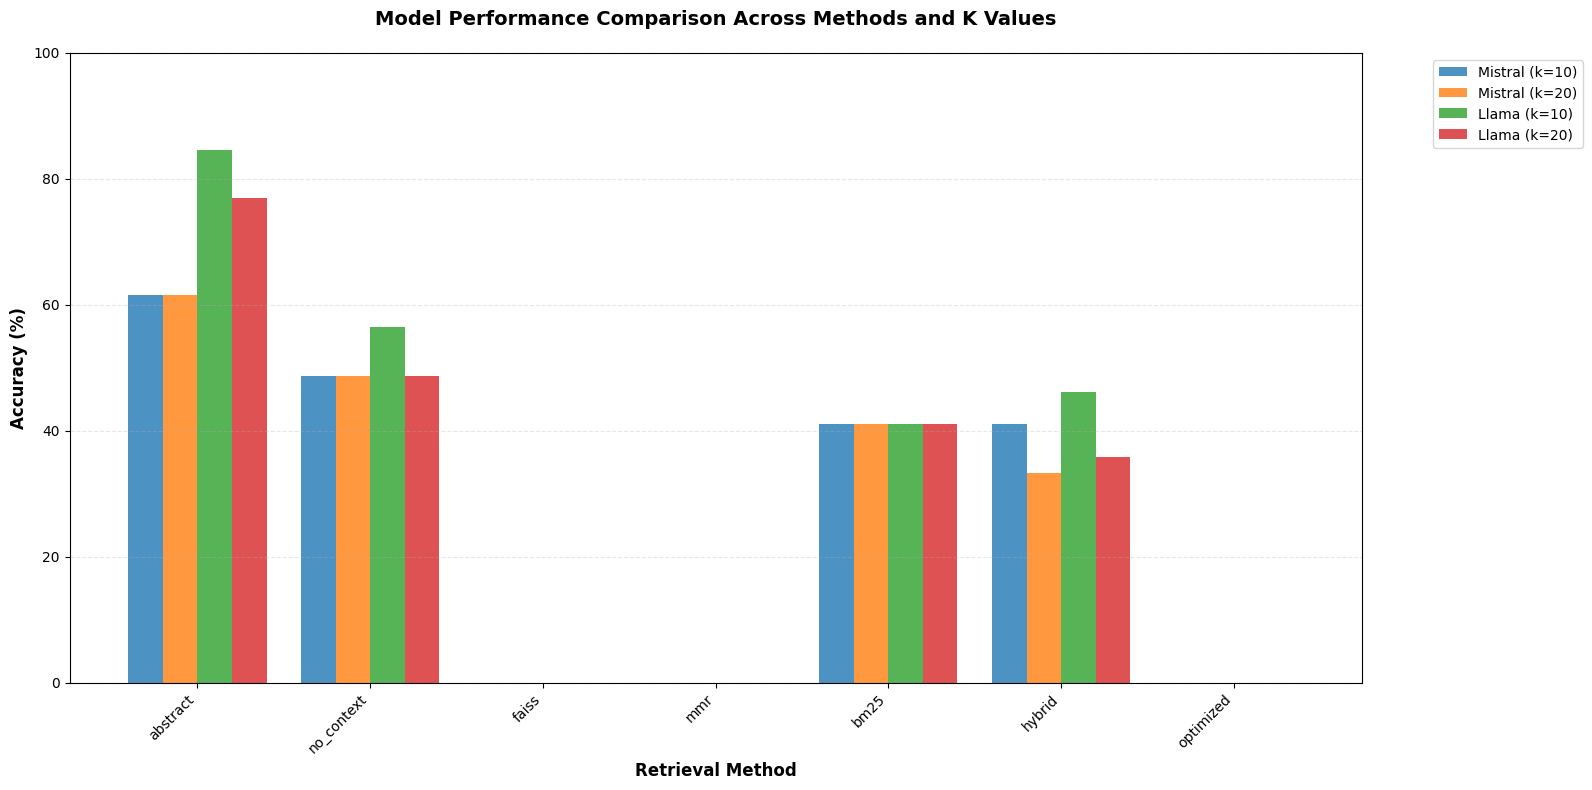

✓ Grouped bar chart generated


In [ ]:
# Visualization 1: Grouped Bar Chart - Models and K values comparison
fig, ax = plt.subplots(figsize=(16, 8))

methods = viz_df['method'].unique()
x = np.arange(len(methods))
width = 0.2

models = viz_df['model'].unique()
k_values = sorted(viz_df['k'].unique())

# Create bars for each model-k combination
for i, model in enumerate(models):
    for j, k in enumerate(k_values):
        offset = width * (i * len(k_values) + j - 1.5)
        data = viz_df[(viz_df['model'] == model) & (viz_df['k'] == k)]
        accuracies = [data[data['method'] == m]['accuracy'].values[0] if len(data[data['method'] == m]) > 0 else 0 
                     for m in methods]
        
        label = f"{model.split('-')[0]} (k={k})"
        ax.bar(x + offset, accuracies, width, label=label, alpha=0.8)

ax.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Methods and K Values', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("✓ Grouped bar chart generated")

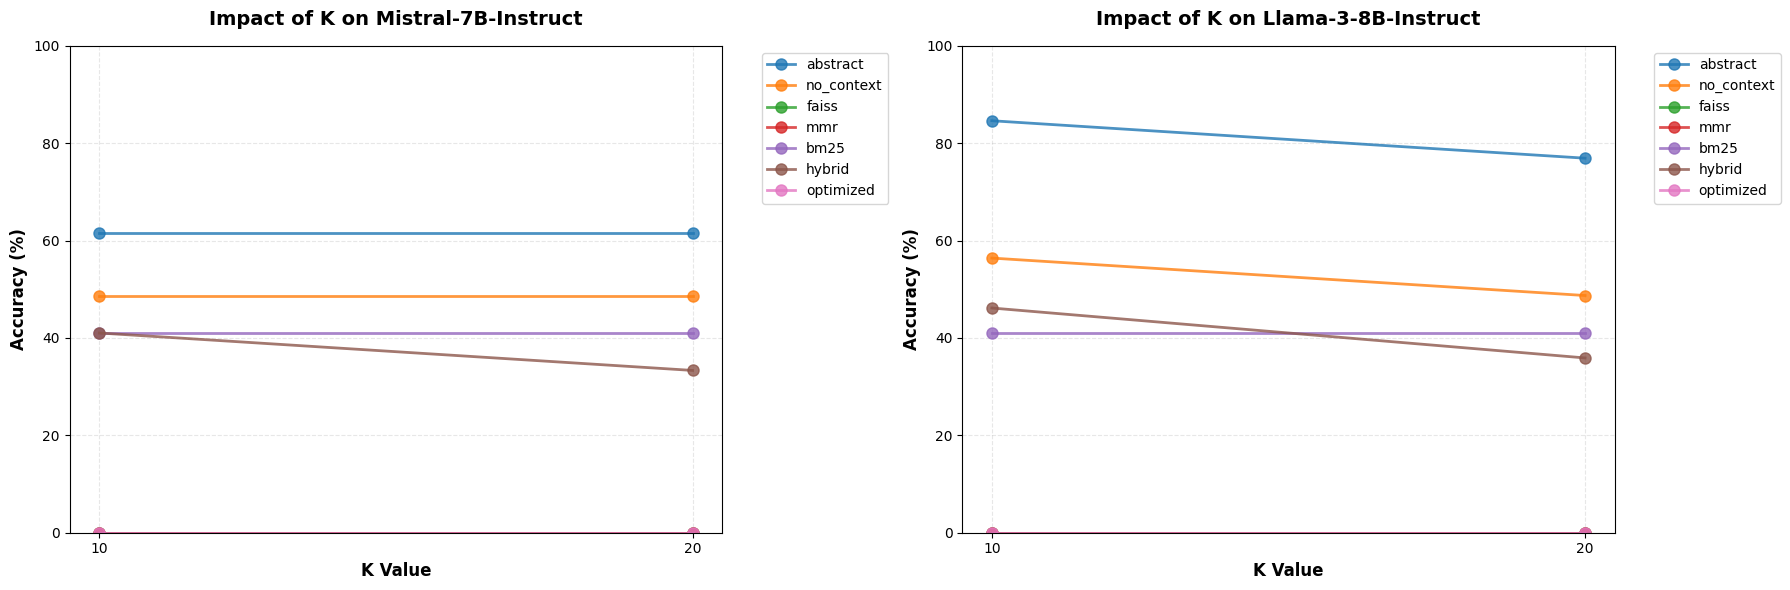

✓ K value impact visualization generated


In [ ]:
# Visualization 3: Line plot showing K value effect for each model
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, model in enumerate(viz_df['model'].unique()):
    ax = axes[idx]
    
    model_data = viz_df[viz_df['model'] == model]
    
    for method in methods:
        method_data = model_data[model_data['method'] == method].sort_values('k')
        ax.plot(method_data['k'], method_data['accuracy'], 
               marker='o', markersize=8, linewidth=2, label=method, alpha=0.8)
    
    ax.set_xlabel('K Value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Impact of K on {model}', fontsize=14, fontweight='bold', pad=15)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks([10, 20])
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("✓ K value impact visualization generated")

In [ ]:
# Statistical Analysis: Model Comparison at Same K
print("\n" + "="*100)
print("MODEL COMPARISON AT SAME K VALUE")
print("="*100)

for k in sorted(viz_df['k'].unique()):
    print(f"\n--- K = {k} ---")
    k_data = viz_df[viz_df['k'] == k]
    
    for method in methods:
        method_data = k_data[k_data['method'] == method]
        print(f"\n{method.upper()}:")
        
        for _, row in method_data.iterrows():
            print(f"  {row['model']:<30}: {row['accuracy']:>6.2f}%")
        
        # Calculate difference
        if len(method_data) == 2:
            diff = abs(method_data.iloc[0]['accuracy'] - method_data.iloc[1]['accuracy'])
            print(f"  {'Δ Difference:':<30}  {diff:>6.2f}%")

print("="*100)


MODEL COMPARISON AT SAME K VALUE

--- K = 10 ---

ABSTRACT:
  Mistral-7B-Instruct           :  61.54%
  Llama-3-8B-Instruct           :  84.62%
  Δ Difference:                    23.08%

NO_CONTEXT:
  Mistral-7B-Instruct           :  48.72%
  Llama-3-8B-Instruct           :  56.41%
  Δ Difference:                     7.69%

FAISS:
  Mistral-7B-Instruct           :   0.00%
  Llama-3-8B-Instruct           :   0.00%
  Δ Difference:                     0.00%

MMR:
  Mistral-7B-Instruct           :   0.00%
  Llama-3-8B-Instruct           :   0.00%
  Δ Difference:                     0.00%

BM25:
  Mistral-7B-Instruct           :  41.03%
  Llama-3-8B-Instruct           :  41.03%
  Δ Difference:                     0.00%

HYBRID:
  Mistral-7B-Instruct           :  41.03%
  Llama-3-8B-Instruct           :  46.15%
  Δ Difference:                     5.13%

OPTIMIZED:
  Mistral-7B-Instruct           :   0.00%
  Llama-3-8B-Instruct           :   0.00%
  Δ Difference:                     0.00%

-

In [ ]:
# Statistical Analysis: K Value Impact per Model per Method
print("\n" + "="*100)
print("K VALUE IMPACT ANALYSIS (K=10 vs K=20)")
print("="*100)

for model in viz_df['model'].unique():
    print(f"\n{'='*100}")
    print(f"MODEL: {model}")
    print(f"{'='*100}")
    
    model_data = viz_df[viz_df['model'] == model]
    
    print(f"{'Method':<15} {'K=10':<12} {'K=20':<12} {'Δ Change':<12} {'Better at':<12}")
    print("-"*100)
    
    for method in methods:
        method_data = model_data[model_data['method'] == method].sort_values('k')
        
        if len(method_data) == 2:
            acc_k10 = method_data.iloc[0]['accuracy']
            acc_k20 = method_data.iloc[1]['accuracy']
            delta = acc_k20 - acc_k10
            better = 'K=20' if delta > 0 else ('K=10' if delta < 0 else 'Equal')
            
            print(f"{method:<15} {acc_k10:>6.2f}%     {acc_k20:>6.2f}%     "
                  f"{delta:>+6.2f}%     {better:<12}")
    
    # Overall summary for this model
    avg_k10 = model_data[model_data['k'] == 10]['accuracy'].mean()
    avg_k20 = model_data[model_data['k'] == 20]['accuracy'].mean()
    print("-"*100)
    print(f"{'AVERAGE':<15} {avg_k10:>6.2f}%     {avg_k20:>6.2f}%     "
          f"{avg_k20-avg_k10:>+6.2f}%")

print("\n" + "="*100)
print("OVERALL INSIGHTS")
print("="*100)

# Count improvements
improvements = 0
degradations = 0
for model in viz_df['model'].unique():
    model_data = viz_df[viz_df['model'] == model]
    for method in methods:
        method_data = model_data[model_data['method'] == method].sort_values('k')
        if len(method_data) == 2:
            delta = method_data.iloc[1]['accuracy'] - method_data.iloc[0]['accuracy']
            if delta > 0:
                improvements += 1
            elif delta < 0:
                degradations += 1

print(f"Improvements with K=20: {improvements}/{improvements+degradations} "
      f"({improvements/(improvements+degradations)*100:.1f}%)")
print(f"Degradations with K=20: {degradations}/{improvements+degradations} "
      f"({degradations/(improvements+degradations)*100:.1f}%)")
print("="*100)


K VALUE IMPACT ANALYSIS (K=10 vs K=20)

MODEL: Mistral-7B-Instruct
Method          K=10         K=20         Δ Change     Better at   
----------------------------------------------------------------------------------------------------
abstract         61.54%      61.54%      +0.00%     Equal       
no_context       48.72%      48.72%      +0.00%     Equal       
faiss             0.00%       0.00%      +0.00%     Equal       
mmr               0.00%       0.00%      +0.00%     Equal       
bm25             41.03%      41.03%      +0.00%     Equal       
hybrid           41.03%      33.33%      -7.69%     K=10        
optimized         0.00%       0.00%      +0.00%     Equal       
----------------------------------------------------------------------------------------------------
AVERAGE          27.47%      26.37%      -1.10%

MODEL: Llama-3-8B-Instruct
Method          K=10         K=20         Δ Change     Better at   
---------------------------------------------------------------

## Final Summary and Recommendations

In [ ]:
# Generate Final Summary Report
print("\n" + "="*100)
print("FINAL SUMMARY REPORT")
print("="*100)

print("\n1. BEST PERFORMING CONFIGURATIONS (Top 5):")
print("-"*100)
top_5 = viz_df.nlargest(5, 'accuracy')
for i, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. {row['model']:<25} | {row['method']:<15} | K={row['k']:<3} | "
          f"{row['accuracy']:.2f}% ({row['correct']}/{row['total']})")

print("\n2. WORST PERFORMING CONFIGURATIONS (Bottom 5):")
print("-"*100)
bottom_5 = viz_df.nsmallest(5, 'accuracy')
for i, (_, row) in enumerate(bottom_5.iterrows(), 1):
    print(f"{i}. {row['model']:<25} | {row['method']:<15} | K={row['k']:<3} | "
          f"{row['accuracy']:.2f}% ({row['correct']}/{row['total']})")

print("\n3. AVERAGE PERFORMANCE BY MODEL:")
print("-"*100)
for model in viz_df['model'].unique():
    avg_acc = viz_df[viz_df['model'] == model]['accuracy'].mean()
    print(f"{model:<30}: {avg_acc:.2f}%")

print("\n4. AVERAGE PERFORMANCE BY METHOD:")
print("-"*100)
for method in methods:
    avg_acc = viz_df[viz_df['method'] == method]['accuracy'].mean()
    print(f"{method:<15}: {avg_acc:.2f}%")

print("\n5. AVERAGE PERFORMANCE BY K VALUE:")
print("-"*100)
for k in sorted(viz_df['k'].unique()):
    avg_acc = viz_df[viz_df['k'] == k]['accuracy'].mean()
    print(f"K={k:<3}: {avg_acc:.2f}%")

print("\n6. RECOMMENDATIONS:")
print("-"*100)
best = viz_df.loc[viz_df['accuracy'].idxmax()]
print(f"✓ For best accuracy: Use {best['model']} with {best['method']} method at K={best['k']}")
print(f"  Expected accuracy: {best['accuracy']:.2f}%")

# Find best by model
print("\n✓ Best configuration by model:")
for model in viz_df['model'].unique():
    model_best = viz_df[viz_df['model'] == model].loc[viz_df[viz_df['model'] == model]['accuracy'].idxmax()]
    print(f"  {model}: {model_best['method']} at K={model_best['k']} ({model_best['accuracy']:.2f}%)")

# Find best by method
print("\n✓ Best model-K combination by method:")
for method in methods:
    method_best = viz_df[viz_df['method'] == method].loc[viz_df[viz_df['method'] == method]['accuracy'].idxmax()]
    print(f"  {method}: {method_best['model']} at K={method_best['k']} ({method_best['accuracy']:.2f}%)")

print("\n" + "="*100)
print("EXPERIMENT COMPLETE - All results saved and analyzed!")
print("="*100)


FINAL SUMMARY REPORT

1. BEST PERFORMING CONFIGURATIONS (Top 5):
----------------------------------------------------------------------------------------------------
1. Llama-3-8B-Instruct       | abstract        | K=10  | 84.62% (33/39)
2. Llama-3-8B-Instruct       | abstract        | K=20  | 76.92% (30/39)
3. Mistral-7B-Instruct       | abstract        | K=10  | 61.54% (24/39)
4. Mistral-7B-Instruct       | abstract        | K=20  | 61.54% (24/39)
5. Llama-3-8B-Instruct       | no_context      | K=10  | 56.41% (22/39)

2. WORST PERFORMING CONFIGURATIONS (Bottom 5):
----------------------------------------------------------------------------------------------------
1. Mistral-7B-Instruct       | faiss           | K=10  | 0.00% (0/0)
2. Mistral-7B-Instruct       | mmr             | K=10  | 0.00% (0/0)
3. Mistral-7B-Instruct       | optimized       | K=10  | 0.00% (0/0)
4. Mistral-7B-Instruct       | faiss           | K=20  | 0.00% (0/0)
5. Mistral-7B-Instruct       | mmr             |

In [ ]:
# Export results to CSV for further analysis
csv_filename = f'results_multimodel_comparison_{timestamp}.csv'
viz_df.to_csv(csv_filename, index=False)
print(f"✓ Results exported to CSV: {csv_filename}")

# Also create a summary CSV with just the key metrics
summary_df = viz_df.groupby(['model', 'k', 'method']).agg({
    'accuracy': 'first',
    'correct': 'first',
    'total': 'first'
}).reset_index()

summary_csv = f'results_summary_{timestamp}.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"✓ Summary exported to CSV: {summary_csv}")

print(f"\n📊 Dataset shape: {viz_df.shape}")
print(f"📊 Total experiments: {len(viz_df)}")
print(f"📊 Models tested: {viz_df['model'].nunique()}")
print(f"📊 Methods tested: {viz_df['method'].nunique()}")
print(f"📊 K values tested: {viz_df['k'].nunique()}")

✓ Results exported to CSV: results_multimodel_comparison_20260217_181139.csv
✓ Summary exported to CSV: results_summary_20260217_181139.csv

📊 Dataset shape: (28, 6)
📊 Total experiments: 28
📊 Models tested: 2
📊 Methods tested: 7
📊 K values tested: 2
